In [1]:
import joblib
import pandas as pd
from numpy.ma.core import log2, size
from streamlit import columns

from marginal_emissions.core.msdr import MSDRAnalyzer

In [2]:
tennet = pd.read_csv('../data/processed/test_final_tennet', index_col=0, decimal=',')

In [3]:
analyzer = MSDRAnalyzer(tso='tennet', data=tennet, run='test2_aic')

In [4]:
vars(analyzer)

{'root': PosixPath('/home/aklei/PycharmProjects/marginal-emissions-germany'),
 'tso': 'tennet',
 'run': 'test2_aic',
 'scaler': StandardScaler(),
 'df':                           total_generation total_emissions
 datetime                                                  
 2022-12-31 23:00:00+00:00           282.75           372.0
 2022-12-31 23:15:00+00:00           282.75           372.0
 2022-12-31 23:30:00+00:00           282.75           372.0
 2022-12-31 23:45:00+00:00           282.75           372.0
 2023-01-01 00:00:00+00:00           281.25          393.16
 ...                                    ...             ...
 2023-01-08 00:15:00+00:00            311.5          418.33
 2023-01-08 00:30:00+00:00            311.5          418.33
 2023-01-08 00:45:00+00:00            311.0          417.52
 2023-01-08 01:00:00+00:00           309.25          412.28
 2023-01-08 01:15:00+00:00            309.5          412.68
 
 [682 rows x 2 columns],
 'window_length': 672,
 'n_jobs': -1,
 'p

In [5]:
analyzer.prepare()

[INFO][2026-02-22 15:18:54][msdr.py] Starting data preparation...
[INFO][2026-02-22 15:18:54][msdr.py] I. DATA INSPECTION
[INFO][2026-02-22 15:18:54][msdr.py] Setting index to datetime...
[INFO][2026-02-22 15:18:54][msdr.py] Setting columns to numeric...

[INSPECTION]
  - Index Type: datetime64[ns, UTC]
  - Duplicate Entries: 0
  - Total Generation Type: float64
  - Negative Generation Values: 0
  - Total Emissions Type: float64
  - Negative Emissions Values: 0
  - Rows with NaN Values: 0

[INFO][2026-02-22 15:18:54][msdr.py] II. DATA PREPARATION
[INFO][2026-02-22 15:18:54][msdr.py] 1) Calculation delta for time series:
[INFO][2026-02-22 15:18:54][msdr.py] Setting index to datetime...
[INFO][2026-02-22 15:18:54][msdr.py] Setting columns to numeric...
                           total_generation  total_emissions
datetime                                                    
2022-12-31 23:15:00+00:00               0.0             0.00
2022-12-31 23:30:00+00:00               0.0             

,total_generation,total_emissions
datetime,,
2022-12-31 23:15:00+00:00,-0.003781,-0.005126
2022-12-31 23:30:00+00:00,-0.003781,-0.005126
2022-12-31 23:45:00+00:00,-0.003781,-0.005126
2023-01-01 00:00:00+00:00,-0.148174,1.810557
2023-01-01 00:15:00+00:00,-0.003781,-0.005126
...,...,...
2023-01-08 00:15:00+00:00,-0.003781,-0.005126
2023-01-08 00:30:00+00:00,-0.003781,-0.005126
2023-01-08 00:45:00+00:00,-0.051912,-0.074630


In [6]:
analyzer.fit()

[INFO][2026-02-22 15:18:54][msdr.py] Starting MSDR analysis for tennet on 10 rows...


Analyzing tennet...: 100%|██████████| 10/10 [00:00<00:00, 486.66it/s]


[INFO][2026-02-22 15:19:02][msdr.py] Analysis for tennet complete.



In [7]:
analyzer.best_model_results[0].params

p[0->0]      0.646685
p[1->0]      0.679767
const[0]    -0.000833
const[1]    -0.027815
x1[0]        0.793621
x1[1]        0.622863
sigma2[0]    0.000397
sigma2[1]    1.709473
dtype: float64

In [8]:
analyzer.compute()

[INFO][2026-02-22 15:19:03][msdr.py] Computing MEF from best models...
[ERROR][2026-02-22 15:19:03][msdr.py] Failed to save model: 'NoneType' object has no attribute 'to_csv'
[INFO][2026-02-22 15:19:03][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/tables/df_mef_scaled.csv
[INFO][2026-02-22 15:19:03][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/summary/indicators.pkl
[INFO][2026-02-22 15:19:03][msdr.py] Inverse transforming coefficients to get absolute MEF
[INFO][2026-02-22 15:19:03][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/tables/df_mef_absolute.csv


In [9]:
analyzer.merge_mef().dropna()

[INFO][2026-02-22 15:19:03][msdr.py] Merging MEF back to original data...
[INFO][2026-02-22 15:19:03][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/tables/df_mef_final.csv


,total_generation,total_emissions,mef_t_MWh,mef_g_kWh,intercept
datetime,,,,,
2023-01-07 23:00:00+00:00,311.50,391.63,0.698749,698.749471,-0.291863
2023-01-07 23:15:00+00:00,311.50,391.63,0.900837,900.837229,0.008926
2023-01-07 23:30:00+00:00,311.50,391.63,0.888734,888.734376,0.012534
2023-01-07 23:45:00+00:00,311.50,391.63,0.900320,900.319553,0.008179
2023-01-08 00:00:00+00:00,311.50,418.33,0.699337,699.336668,-0.271780
2023-01-08 00:15:00+00:00,311.50,418.33,0.888983,888.983304,0.013066
2023-01-08 00:30:00+00:00,311.50,418.33,0.900328,900.327833,0.008393
2023-01-08 00:45:00+00:00,311.00,417.52,0.896295,896.294607,0.002191
2023-01-08 01:00:00+00:00,309.25,412.28,0.699135,699.134776,-0.308763


In [18]:
analyzer.best_model_results[0].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Markov Switching Model Results                        
==============================================================================
Dep. Variable:        total_emissions   No. Observations:                  672
Model:               MarkovRegression   Log Likelihood                 334.782
Date:                Sun, 22 Feb 2026   AIC                           -653.565
Time:                        15:21:46   BIC                           -617.483
Sample:                    12-31-2022   HQIC                          -639.591
                         - 01-07-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.001     -0.783      0.433      -0.003       0.001
x1             0.7936      0.004    213.816      0.000       0.786       0.801
sigma2         0.0004   4.71e-05      8.415      0.000       0.000       0.000
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0278      0.087     -0.321      0.748      -0.197       0.142
x1             0.6229      0.053     11.727      0.000       0.519       0.727
sigma2         1.7095      0.165     10.386      0.000       1.387       2.032
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        0.6467      0.024     26.478      0.000       0.599       0.695
p[1->0]        0.6798      0.034     19.783      0.000       0.612       0.747
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
"""

In [11]:
import matplotlib.pyplot as plt
mef1 = pd.read_csv('../results/tennet_run_test1_mae/tables/df_mef_final.csv', index_col=0)
mef1.drop(columns=['total_generation', 'total_emissions', 'mef_t_MWh', 'intercept'], inplace=True)
mef2 = pd.read_csv('../results/tennet_run_test2_aic/tables/df_mef_final.csv', index_col=0)
mef2.drop(columns=['total_generation', 'total_emissions', 'mef_t_MWh', 'intercept'], inplace=True)
total_emissions_df = pd.read_csv('../results/tennet_run_test2_aic/tables/df_mef_final.csv', index_col=0)
total_emissions_df.drop(columns=['total_generation', 'mef_t_MWh', 'intercept', 'mef_g_kWh'], inplace=True)
print(f"mef1 = [{mef1.columns}], mef2 = [{mef2.columns}], total_emissions = [{total_emissions_df.columns}]")

mef1 = [Index(['mef_g_kWh'], dtype='object')], mef2 = [Index(['mef_g_kWh'], dtype='object')], total_emissions = [Index(['total_emissions'], dtype='object')]


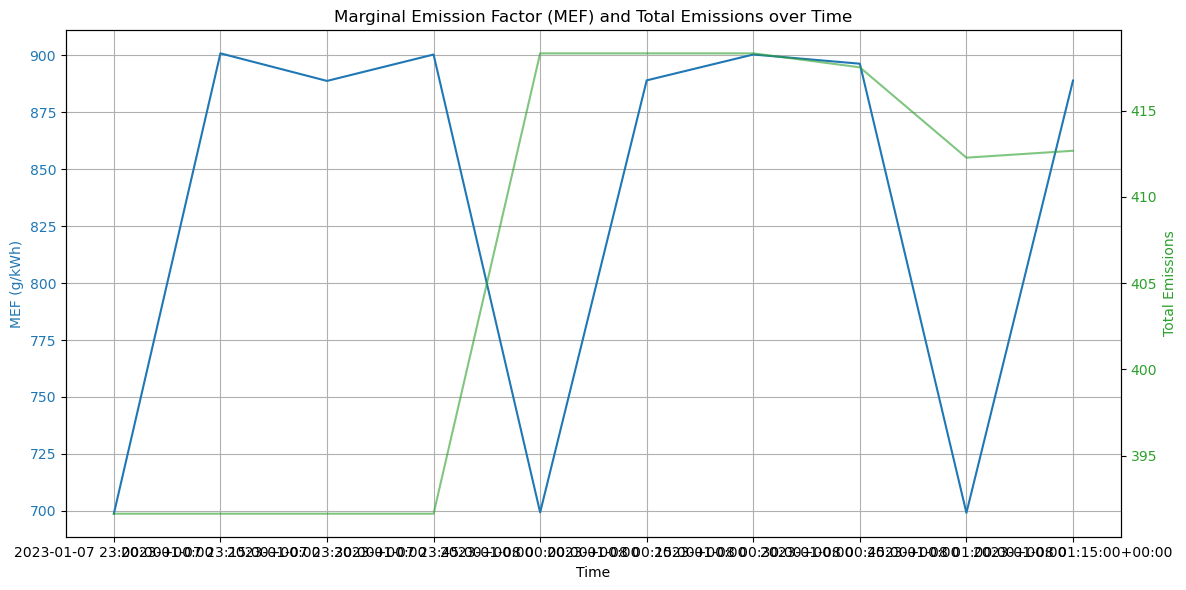

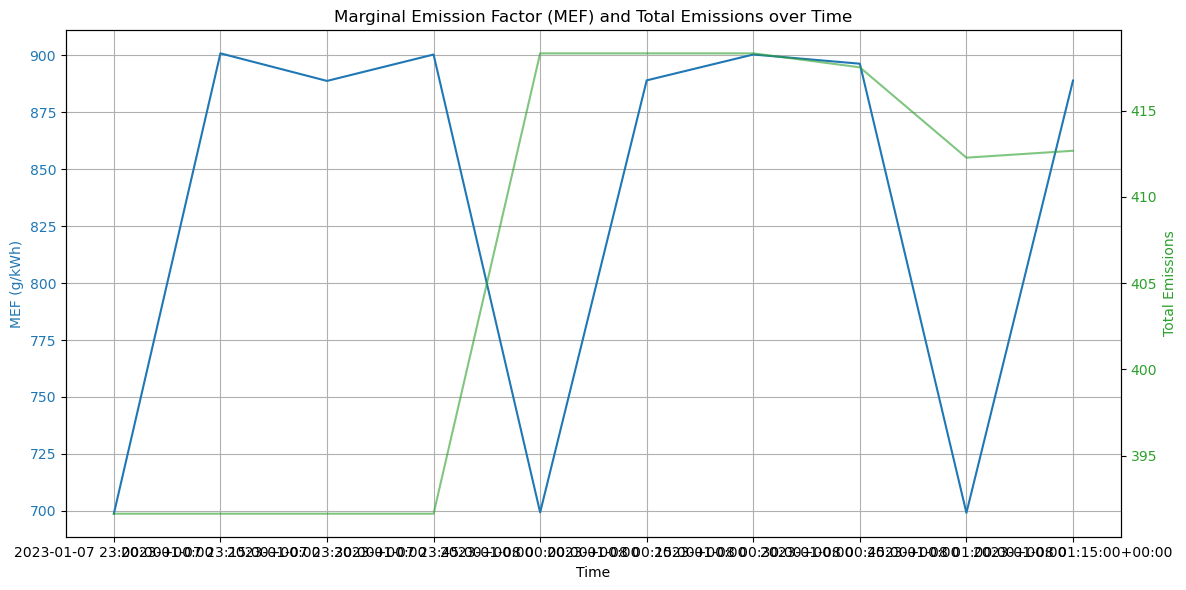

In [12]:
for mef in [mef1, mef2]:

    # Filter only rows where MEF has values (drop NaNs)
    mef_plot = mef.dropna()

    # Create a figure and a primary axis
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot MEF on the primary axis (left y-axis)
    color = 'tab:blue'
    ax1.set_xlabel('Time')
    ax1.set_ylabel('MEF (g/kWh)', color=color)
    ax1.plot(mef_plot.index, mef_plot, color=color, label='MEF (g/kWh)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    # Create a secondary axis sharing the same x-axis
    ax2 = ax1.twinx()

    # Plot Total Emissions on the secondary axis (right y-axis)
    # We need to align the index with mef to ensure same period
    current_emissions = total_emissions_df.loc[mef_plot.index, 'total_emissions']

    color = 'tab:green'
    ax2.set_ylabel('Total Emissions', color=color)
    ax2.plot(current_emissions.index, current_emissions, color=color, label='Total Emissions (tCO2)', alpha=0.6)
    ax2.tick_params(axis='y', labelcolor=color)

    # Title and layout
    plt.title('Marginal Emission Factor (MEF) and Total Emissions over Time')
    fig.tight_layout()  # Adjust the layout to prevent clipping
    plt.show()

In [13]:
vars(analyzer.best_model_results[0].mlefit)

{'params': array([ 6.04497660e-01,  7.52699145e-01, -8.32969412e-04, -2.78146051e-02,
         7.93620954e-01,  6.22862655e-01,  1.99138093e-02,  1.30746812e+00]),
 'model': <statsmodels.tsa.regime_switching.markov_regression.MarkovRegression at 0x75d90da3d550>,
 'k_constant': 1,
 '_data_attr': [],
 '_data_in_cache': ['fittedvalues', 'resid', 'wresid'],
 'normalized_cov_params': None,
 'scale': 1.0,
 '_use_t': False,
 'mle_retvals': {'fopt': np.float64(-0.4981880472047466),
  'gopt': array([ 4.53299432e-08, -3.45981685e-08, -3.80415846e-06, -1.52176453e-07,
          8.84500527e-07,  6.97218296e-07,  5.24839447e-06,  1.22580475e-08]),
  'Hinv': array([[ 6.95054402e+00, -1.69665113e-01, -6.43649407e-04,
          -6.78701040e-02,  1.80359502e-02, -1.17181382e-01,
           1.56078020e-02,  2.45251966e-01],
         [-1.69665113e-01,  1.43499203e+01,  4.08872574e-04,
           4.82735807e-01,  3.33685203e-02,  5.61718496e-01,
           2.81736571e-02,  5.52461429e-01],
         [-6.43

In [38]:
import joblib
res = joblib.load('../results/tennet_run_test1_mae/summary/summary.pkl')

In [53]:
res[0]['coeffs']['coef']['sigma2[0]']

np.float64(0.00039655980140440713)

In [54]:
for i in range(len(res)):
    params = analyzer.best_model_results[i]
    print(f"Converged: {res[i]['mle_converged']}")
    print(f"No. Regimes: {res[i]['k_regimes']}")
    print(f"AIC: {res[i]['aic']}")
    print(f"MAE: {res[i]['mae']}\n")
    print(f"Variance MEF: {res[i]['coeffs']['coef']['sigma2[0]']}")
    #print("")

Converged: True
No. Regimes: 2
AIC: -653.5647354431794
MAE: 0.2928070193039523

Variance MEF: 0.00039655980140440713
Converged: True
No. Regimes: 2
AIC: -661.0073408053739
MAE: 0.2891554125998796

Variance MEF: 0.0004585788831313382
Converged: True
No. Regimes: 2
AIC: -653.6650329441316
MAE: 0.2928017574644449

Variance MEF: 0.00039682531130521165
Converged: True
No. Regimes: 2
AIC: -660.8369712700371
MAE: 0.2862850284039905

Variance MEF: 0.0004584278668596474
Converged: True
No. Regimes: 2
AIC: -652.6097994561308
MAE: 0.2932946431153779

Variance MEF: 0.0003969321563495097
Converged: True
No. Regimes: 2
AIC: -652.7102095818229
MAE: 0.2932898728324579

Variance MEF: 0.0003972005663570109
Converged: True
No. Regimes: 2
AIC: -660.0598443978892
MAE: 0.28966361301837423

Variance MEF: 0.00045885310551203363
Converged: True
No. Regimes: 2
AIC: -657.7434716068731
MAE: 0.2891348956686857

Variance MEF: 0.0004634538348506193
Converged: True
No. Regimes: 2
AIC: -650.0204379199522
MAE: 0.293297

In [ ]:
import joblib
summary2 = joblib.load('../results/tennet_run_test2_aic/summary/summary.pkl')

In [ ]:
for i in range(len(summary2)):
    params = analyzer.best_model_results[i]
    summary2 = analyzer.summary
    print(f"Converged: {summary2[i]['mle_converged']}")
    print(f"No. Regimes: {summary2[i]['k_regimes']}")
    print(f"AIC: {summary2[i]['aic']}")
    print(f"MAE: {summary2[i]['mae']}\n")